In [1]:
import numpy as np


In [2]:
# Load data from data/parsed

train_data = np.load("data/parsed/train.npz")
test_data = np.load("data/parsed/test.npz")
print("Train data keys:", train_data.files)


Train data keys: ['inputs', 'targets', 'feature_labels', 'class_labels', 'extra_vars']


# Plot the distribution of labels

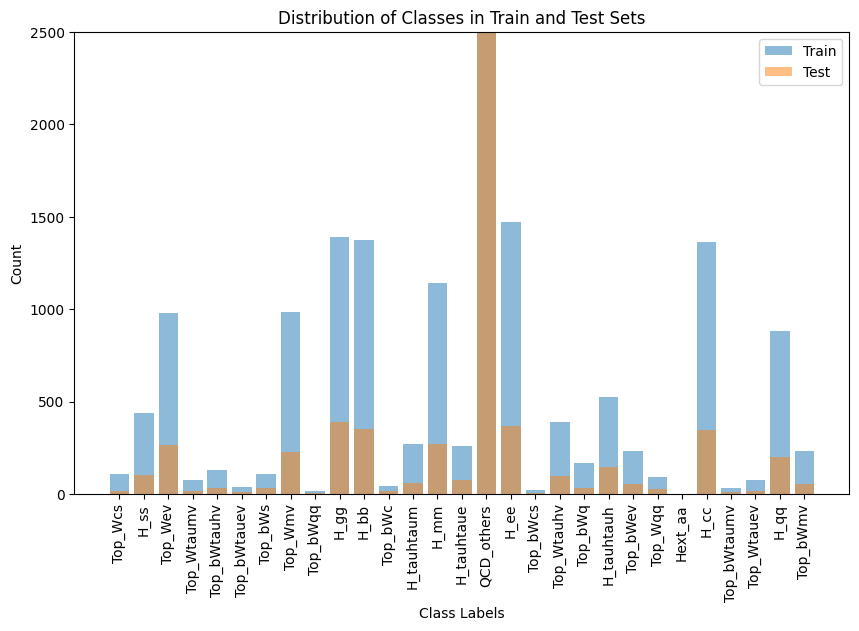

In [3]:
import matplotlib.pyplot as plt

train_counts = np.sum(train_data["targets"], axis=0)
test_counts = np.sum(test_data["targets"], axis=0)

plt.figure(figsize=(10,6))
plt.bar(train_data["class_labels"], train_counts, alpha=0.5, label="Train")
plt.bar(test_data["class_labels"], test_counts, alpha=0.5, label="Test")
plt.xticks(rotation=90)
plt.xlabel("Class Labels")
plt.ylabel("Count")
plt.ylim(0, 2500)  # Set y-axis limit for better visibility
#plt.yscale("log")  # Use logarithmic scale for better visibility
plt.title("Distribution of Classes in Train and Test Sets")
plt.legend()
plt.show()

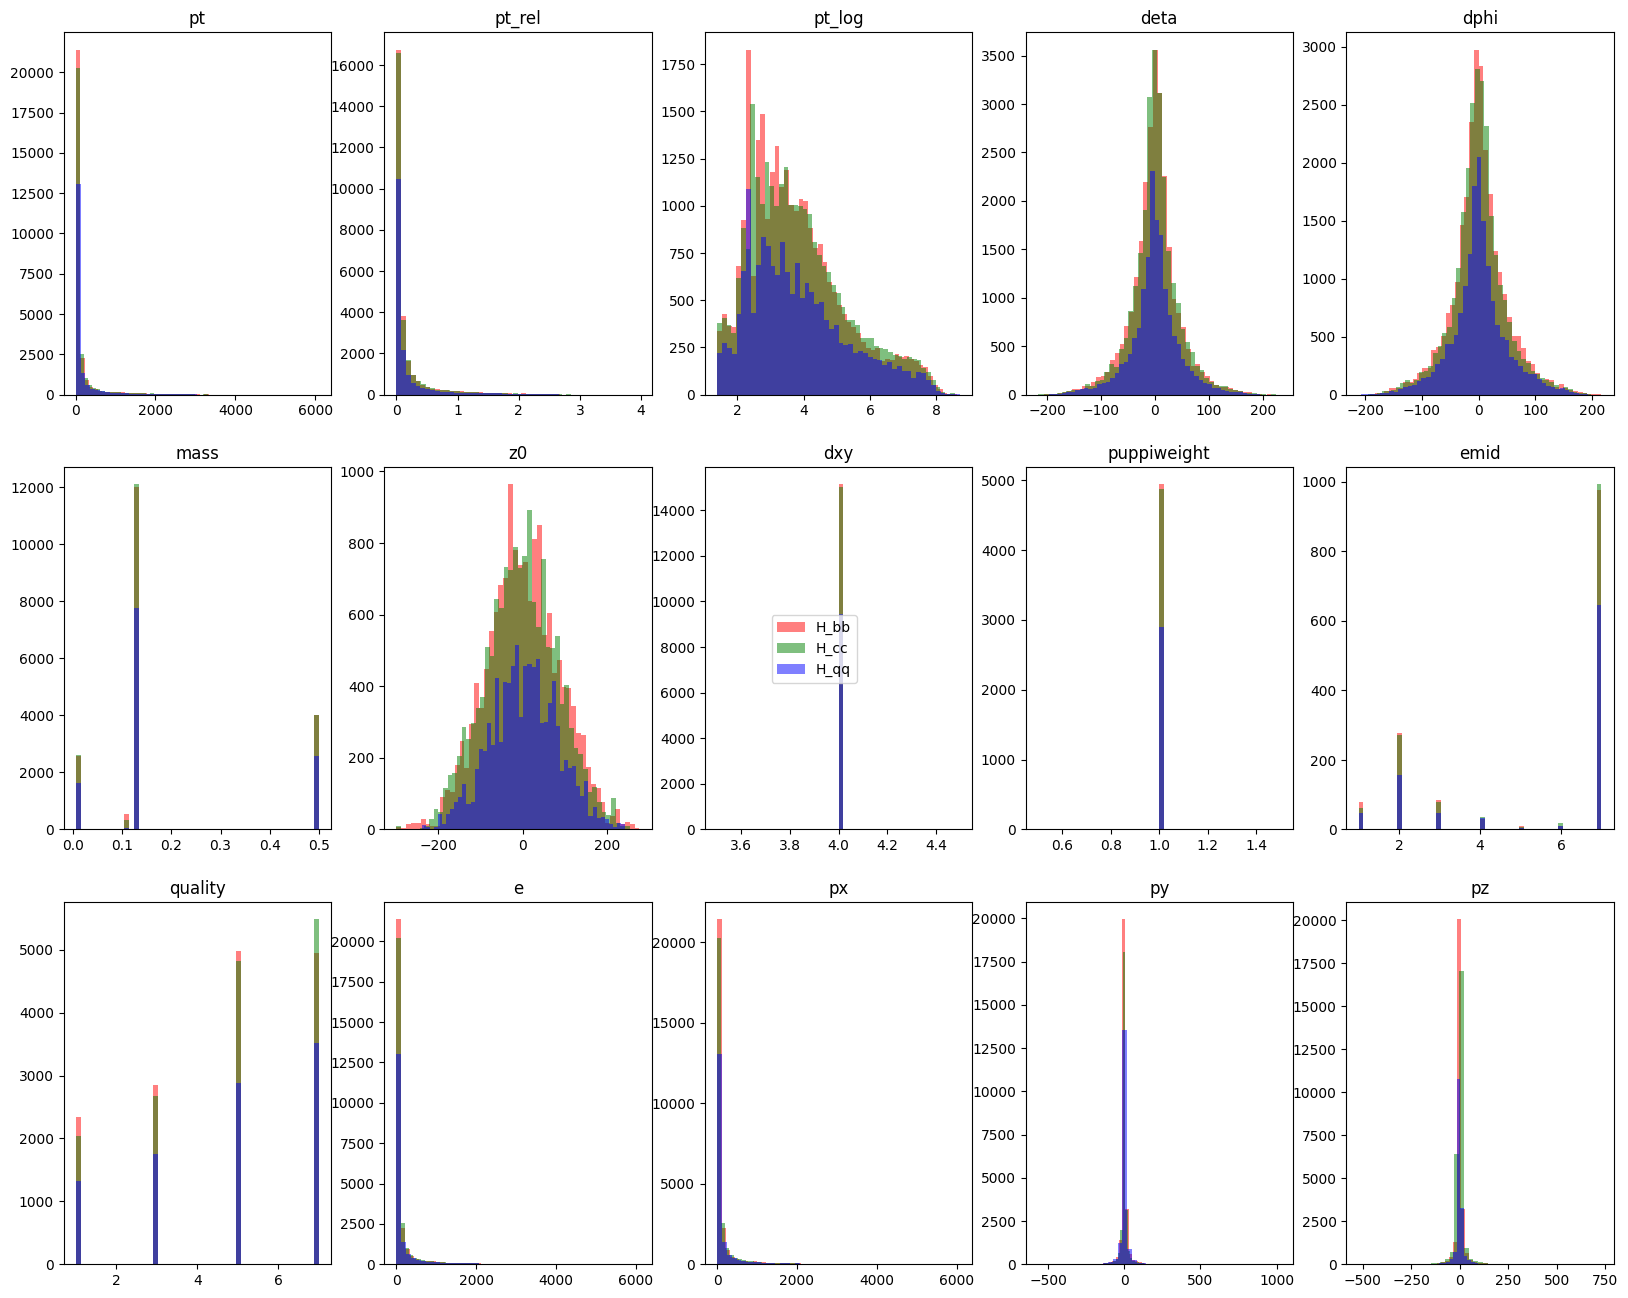

In [ ]:


import json


subset_classes = ["H_bb", "H_cc", "H_qq"]
subset_label_idx = [i for i, label in enumerate(train_data["class_labels"]) if label in subset_classes]
subset_mask = np.isin(train_data["targets"].argmax(axis=1), subset_label_idx)
colors = ["red", "green", "blue"]
cl_to_col = {label: color for label, color in zip(subset_classes, colors)}

fig, ax = plt.subplots(figsize=(20,16), nrows=3, ncols=5)
ax = ax.flatten()

for idx, label in zip(subset_label_idx, subset_classes):
    mask = np.isin(train_data["targets"].argmax(axis=1), idx)
    subset_features = train_data["inputs"][mask]

    variable_names = json.load(open("data/parsed/variables.json"))
    feature_names = variable_names["inputs"]

    features = zip(feature_names, subset_features.T)
    i = 0   
    for name, values in features:
        if "is" in name:
            continue  # Skip binary features
        if np.ndim(values) > 1:
            values = values.flatten()
        values = values[~np.isnan(values)]  # Remove NaN values
        values = values[values != 0]  # Remove zero values
        ax[i].hist(values, bins=50, color=cl_to_col[label], alpha=0.5)
        ax[i].set_title(name)
        i += 1
#plt.tight_layout()
fig.legend(subset_classes, loc="center")
plt.show()